## Section RNN - Autoregressive Linear Model

In [1]:
import torch
import torch.nn as nn
import torch.optim as opt
import numpy as  np
import matplotlib.pyplot as plt

## create datasest

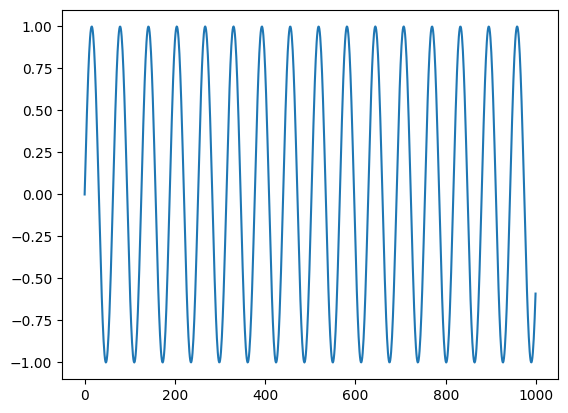

In [2]:
N = 1000

series = np.sin(0.1*np.arange(N)) # np.random.randn(N)*0.1
plt.plot(series)
plt.show()

In [3]:
#define dataset stuff

T = 10
D = 1
S = 1
# N = floor((L-T)/s)+1 => S(N-1)+T = L

X,y = [],[]

for t in range(N-T):
    X.append(series[t:t+T])
    y.append(series[t+T])

X = np.array(X).reshape(-1,T)
y = np.array(y).reshape(-1,1)
print(X.shape)
print(y.shape)
N = X.shape[0]

(990, 10)
(990, 1)


## define model

In [4]:
model = nn.Linear(T,1)
criterion = nn.MSELoss()
optimizer = opt.Adam(model.parameters(),lr=0.1)

train test split to half of the dataset


In [5]:
X_train = torch.from_numpy(X[:N//2].astype(np.float32))
X_test = torch.from_numpy(X[N//2:].astype(np.float32))
y_train = torch.from_numpy(y[:N//2].astype(np.float32))
y_test = torch.from_numpy(y[N//2:].astype(np.float32))

## train it all

In [6]:
epochs = 200
train_losses = []
test_losses = []
for epoch in range(epochs):
  
    optimizer.zero_grad()

    y_hat = model(X_train)

    loss = criterion(y_hat,y_train)
    loss.backward()
    optimizer.step()

    train_losses.append(criterion(y_hat,y_train).item())
    y_tst_hat = model(X_test)
    test_losses.append(criterion(y_tst_hat,y_test).item())
    print(f"train loss {train_losses[-1]} test loss: {test_losses[-1]}")

train loss 0.45163941383361816 test loss: 0.07991033047437668
train loss 0.07969799637794495 test loss: 0.2619255483150482
train loss 0.26756033301353455 test loss: 0.23087845742702484
train loss 0.23622505366802216 test loss: 0.08704520016908646
train loss 0.0888136476278305 test loss: 0.027635416015982628
train loss 0.027027981355786324 test loss: 0.07468573749065399
train loss 0.07421930134296417 test loss: 0.11676627397537231
train loss 0.11737951636314392 test loss: 0.08952812850475311
train loss 0.09048274159431458 test loss: 0.031380776315927505
train loss 0.03187096491456032 test loss: 0.003557221032679081
train loss 0.0035647826734930277 test loss: 0.023290105164051056
train loss 0.023297566920518875 test loss: 0.05469527840614319
train loss 0.054969873279333115 test loss: 0.05795542895793915
train loss 0.05830550566315651 test loss: 0.03336835280060768
train loss 0.03351254388689995 test loss: 0.010292891412973404
train loss 0.01024294551461935 test loss: 0.010863309726119041

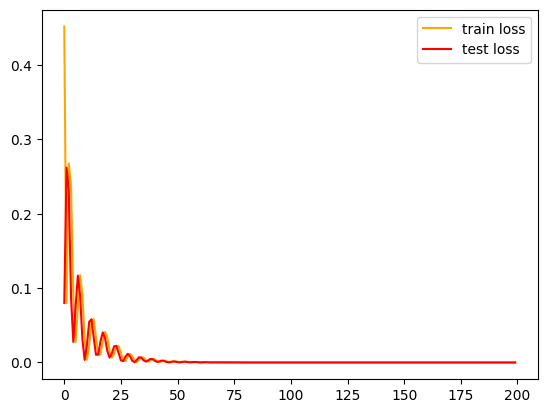

In [7]:
ticks = [x for x in range(len(train_losses))]

plt.plot(ticks,train_losses,label='train loss',color='orange')
plt.plot(ticks,test_losses,label='test loss',color='red')
plt.legend()

<span ><h1 style="color:red"><b>Now let's forecast THE WRONG WAY</b></h1></span>

In [15]:
validation_targets = y[N//2:]
validation_predictions = []
val_idx = 0

while len(validation_predictions) < len(validation_targets):
    inputs = X_test[val_idx].view(1,-1)
    pred = model(inputs)
    validation_predictions.append(pred[0,0].item())
    val_idx += 1


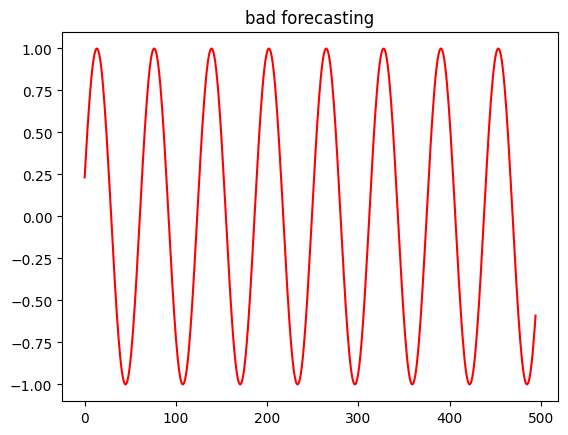

In [13]:
plt.title('bad forecasting')
plt.plot(validation_predictions,color='red')

again we took from test T samples a predicted the next then we again took T samples from test and predicted the next <b style="color:red">without considering the previous predictions</b>

<h1><b>Now let's forecast THE RIGHT WAY</b></h1>

In [86]:
val_idx = 0 
validation_targets = y[-N//2:]
validation_predictions = []
last_x = torch.from_numpy(X[-N//2].astype(np.float32))

In [87]:
while len(validation_predictions) < len(validation_targets) :
    inputs = last_x.view(1,-1)
    pred = model(inputs)
    validation_predictions.append(pred[0,0].item())
    val_idx += 1
    last_x = torch.cat((last_x[1:],pred[0]))
  

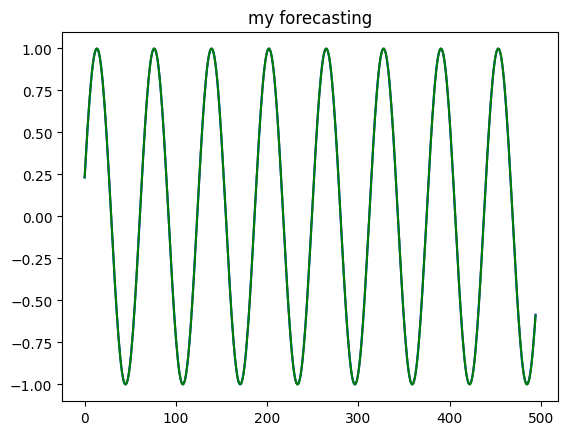

In [88]:
plt.title('my forecasting')
plt.plot(validation_predictions,color='blue')
plt.plot(validation_targets,color='green')